In [5]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "/home/ashwin/Desktop/ashwin_md/LD/lmp/tests/Oct2025"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Oct2025/"

colors = ["darkorange", "olive", "orangered", "crimson", "#2544D0", "goldenrod", "k"]

In [6]:
def wca_pot(r, shift):
    epsilon = 1
    R = 1
    pe = 4*epsilon*((R/r)**12 - (R/r)**6) + shift
    return(pe)

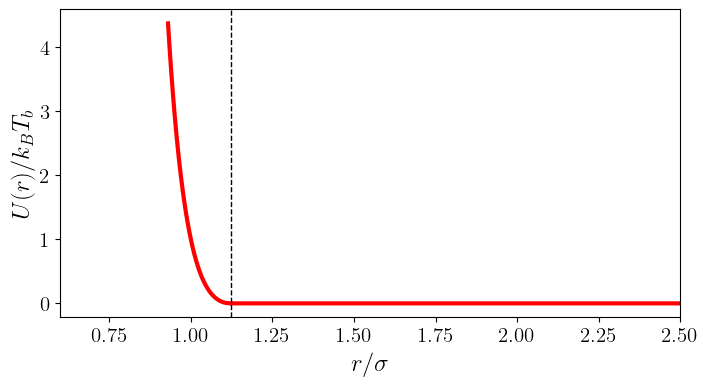

In [4]:
rcut = 2**(1/6)

r = np.arange(0.93, 2.5, 0.005)
wca = []

for rij in r:
    if(rij <= rcut): wca.append(wca_pot(rij, 1))
    else: wca.append(0)

fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(r, wca, "r-", lw = 3)
ax.axvline(x = rcut, ymin = 0, ymax = 1, color = "k", linestyle = "--", lw = 1)
ax.set_xlabel(r"$r/\sigma$", fontsize = 18)
ax.set_ylabel(r"$U(r)/k_BT_b$", fontsize = 18)
ax.set(xlim = (0.6, 2.5))
ax.tick_params(axis='both', which = 'major', labelsize = 15)
# ax.set_title("Weeks Chandler Anderson (WCA) potential", fontsize = 12)

# fig.savefig(os.path.join(figpath, "wca.png"), dpi = 500, bbox_inches = "tight")

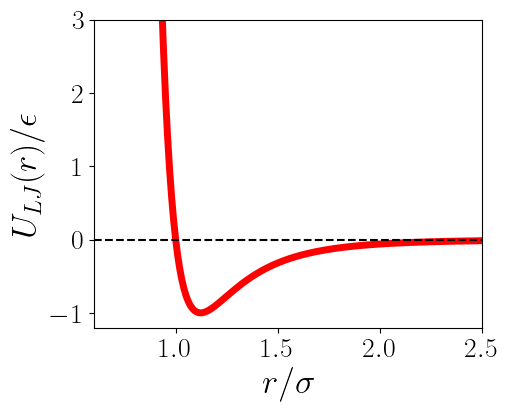

In [7]:
rcut = 2**(1/6)

r = np.arange(0.93, 2.5, 0.005)
lj = []

for rij in r:
    lj.append(wca_pot(rij, 0))
    # if(rij <= rcut): wca.append(wca_pot(rij, 0))
    # else: wca.append(0)

fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(r, lj, "r-", lw = 5, label = r"$\textrm{Lennard Jones 6-12}$")
ax.axhline(y = 0, xmin = 0, xmax = 1, ls = "--", color = "k", lw = 1.5)
# ax.axvline(x = rcut, ymin = 0, ymax = 1, color = "k", linestyle = "--", lw = 1)

ax.set_xlabel(r"$r/\sigma$", fontsize = 25)
ax.set_ylabel(r"$U_{LJ}(r)/\epsilon$", fontsize = 25)
ax.set(xlim = (0.6, 2.5), ylim = (-1.2, 3))
ax.tick_params(axis='both', which = 'major', labelsize = 20)
# ax.legend(fontsize = 12)
# ax.set_title("Weeks Chandler Anderson (WCA) potential", fontsize = 12)

# fig.savefig(os.path.join(figpath, "lj.png"), dpi = 500, bbox_inches = "tight")